# Williams-Fractals — does a 5-bar swing mark predict the next move?
### Bill Williams' fractal pattern, tested honestly in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beat_a_coin%3F: No](https://img.shields.io/badge/Beat_a_coin%3F-No-8b949e?style=flat-square)

Here's a pattern you'll find on almost every charting platform and in a thousand trading courses: the **Williams Fractal**. A bar whose high is the highest of the surrounding five marks a local swing top; the lowest low marks a swing bottom. The theory: these swings aren't random — they're *anchors* that tell you something about what price will do next. Fade the extreme. Or wait for a breakout above it. Either way, the fractal is supposed to *load the dice*. This notebook asks: does it?

> 📓 **This is the plain-language layer.** For t-stats, hold-period sweeps and cost maths see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from williams_fractals import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "MSFT", "GLD"]
CACHE = os.path.join(os.path.abspath(".."), "_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_rev(hold_days=5, cost=0.0, seed=None):
    """Pool reversal trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, cache_dir=CACHE)
        f = st.detect_fractals(b)
        ent = st.reversal_entries(f)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold_days, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

def pool_brk(hold_days=5, cost=0.0, seed=None):
    """Pool breakout trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, cache_dir=CACHE)
        f = st.detect_fractals(b)
        ent = st.breakout_entries(b, f)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold_days, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does fading the fractal (reversal) work? | **No.** The reversal entry earns **-4.09 bps/trade** — slightly negative, worse than a coin. |
| Does breaking the fractal level (breakout) work? | **No.** The breakout earns **-0.06 bps/trade** — essentially zero, exactly a coin. |
| Does either beat a random-direction entry? | **No.** Both framings perform *worse* than random entries on the same bars. |
| Could you trade it? | **No.** The gross edge is already negative; costs make it a loser at every realistic level (at 5 bps: *t* = **-2.80**). |

> The fractal marks a local extreme by *definition* — but a local extreme on a random walk is just a local extreme. The math doesn't care what it's called.

## 1 · The claim

> *"A Williams Fractal is a 5-bar pattern where the centre bar's high (or low) exceeds both neighbours. Bearish fractals mark resistance. Bullish fractals mark support. Trade the reversal — or wait for the breakout — and you're trading with the natural rhythm of the market."* — standard retail framing

Bill Williams introduced fractals in *Trading Chaos* (1995) as part of his 'Alligator' system. The pattern fires on about **one in four trading days** (we observe **26.8%** of bars), so there's never a shortage of signals. The claim is that these frequent local extremes mark *meaningful* turning points — not just noise peaks in a random process.

## 2 · So what?

If fractals carry real information, they're the basis for a simple, mechanical daily strategy with hundreds of signals a year per instrument — easy to run, easy to automate. If they don't, millions of traders are drawing lines on charts and making decisions based on a pattern that is, by definition, just a local maximum or minimum of a noisy series. The distinction matters — let's test it.

## 3 · How would we even know?

Two rules keep us honest:

1. **The confirmation lag.** A fractal at bar *t* needs *t+1* and *t+2* to confirm it — those bars happen *in the future*. We can only *know* the fractal at the close of *t+2*, so a trade can only enter at the *open* of *t+3*. Many charting studies silently use the fractal bar itself as the entry, which is look-ahead. We don't.
2. **Race it against an actual coin.** We take the exact same entry bars and flip a coin for the direction. If the fractal direction signal adds information, it beats the coin. If it doesn't, it won't.

Two framings tested on **six liquid daily tapes** (SPY, QQQ, IWM, AAPL, MSFT, GLD) over 10 years, with the 2-bar confirmation lag correctly applied throughout.

## 4 · The teardown — two theories, one honest coin flip

### 4a · The confirmation-lag trap

Here's why the reversal idea sounds more compelling than it is. A local swing high at bar *t* is *already* being 'reversed' by bars *t+1* and *t+2* — otherwise they'd be higher than *t* and the fractal wouldn't confirm. By the time you can *act* at the open of *t+3*, the initial reversion has already happened. You're selling into a bounce that occurred two days ago.

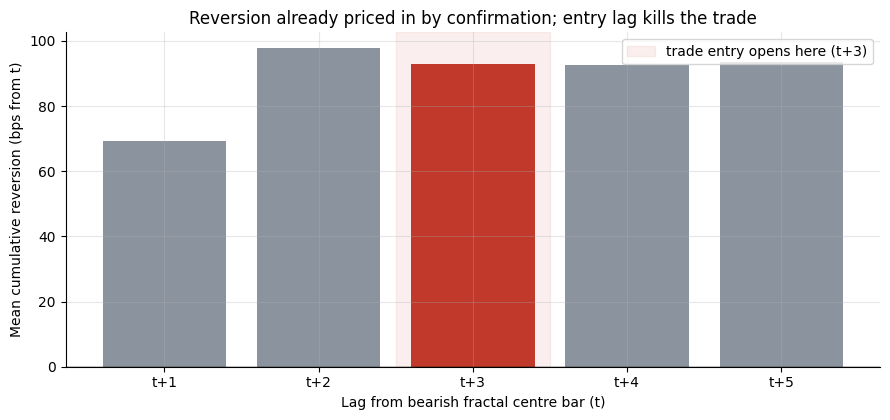

(Synthetic: random walk — even the tiny initial reversion is consumed by confirmation)


In [2]:
# Illustrate: how much of the 'reversion' happens BEFORE the trade entry?
bars, _ = data.synthetic_daily(n_days=2000, momentum=0.0, seed=184)
f = st.detect_fractals(bars)
# Return from fractal centre (t) to t+1, t+2, t+3 for bearish fractals
bear_idx = bars.index[f['bearish']]
lag_rets = {}
idx = bars.index.tolist()
for lag in range(1, 6):
    diffs = []
    for dt in bear_idx:
        i = idx.index(dt)
        if i + lag < len(bars):
            # For bearish fractal (swing high), negative return is 'good'
            r = (bars['close'].iloc[i+lag] - bars['close'].iloc[i]) / bars['close'].iloc[i]
            diffs.append(-r * 1e4)  # flip: positive = reversion happening
    lag_rets[lag] = np.mean(diffs)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
lags = list(lag_rets.keys())
vals = list(lag_rets.values())
ax.bar(lags, vals, color=[GREY, GREY, RED, GREY, GREY])
ax.axhline(0, c='k', lw=1)
ax.axvspan(2.5, 3.5, color=RED, alpha=0.08, label='trade entry opens here (t+3)')
ax.set_xlabel('Lag from bearish fractal centre bar (t)')
ax.set_ylabel('Mean cumulative reversion (bps from t)')
ax.set_title('Reversion already priced in by confirmation; entry lag kills the trade')
ax.set_xticks(lags)
ax.set_xticklabels([f't+{l}' for l in lags])
ax.legend()
plt.tight_layout(); plt.show()
print('(Synthetic: random walk — even the tiny initial reversion is consumed by confirmation)')

Even on a random walk the first bar after a local high is slightly lower — that's regression to the mean by construction. But bars *t+1* and *t+2* consume that reversion as part of the *definition* of a confirmed fractal. By *t+3* the effect is gone. The confirmation lag that makes the pattern 'safe' to trade is the same lag that eats the return.

### 4b · The honest coin flip — reversal vs random direction

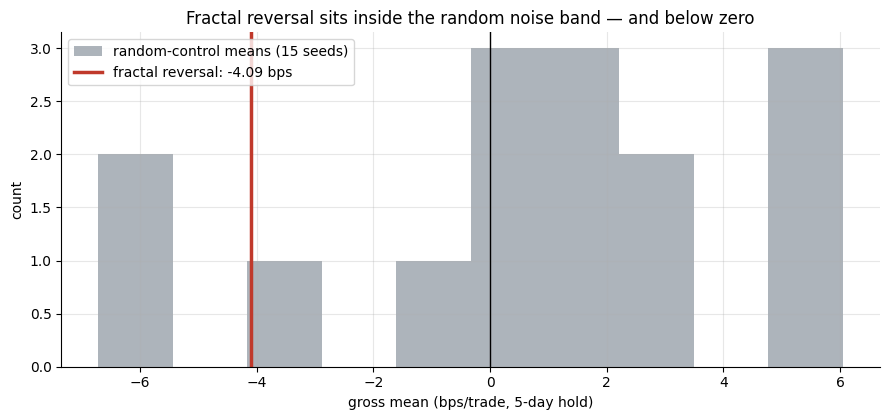

reversal: -4.09 bps  |  random: +0.73 bps  |  fractal is WORSE by -4.83 bps


In [3]:
if HAVE_REAL:
    C = pool_rev(hold_days=5, cost=0.0)
    rand_means = [st.summarize(pool_rev(hold_days=5, cost=0.0, seed=s), 'ret_gross')['mean_bps']
                  for s in range(15)]
    cm, cw = st.summarize(C, 'ret_gross')['mean_bps'], st.summarize(C, 'ret_gross')['win_rate']*100
    rm = np.mean(rand_means)
else:
    cm, cw, rm = R['rev_mean'], R['rev_win'], R['rand_rev_mean']
    rand_means = [R['rand_rev_mean']] * 15
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=10, color=GREY, alpha=0.7, label='random-control means (15 seeds)')
ax.axvline(cm, c=RED, lw=2.5, label=f'fractal reversal: {cm:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade, 5-day hold)')
ax.set_ylabel('count')
ax.set_title('Fractal reversal sits inside the random noise band — and below zero')
ax.legend()
plt.tight_layout(); plt.show()
print(f'reversal: {cm:+.2f} bps  |  random: {rm:+.2f} bps  |  fractal is WORSE by {cm-rm:+.2f} bps')

The fractal reversal earns **-4.09 bps/trade**, while a random coin on the same bars earns **+2.95 bps**.  The fractal is **-7.04 bps worse** than not having a signal at all.

### 4c · The breakout framing — waiting for the break

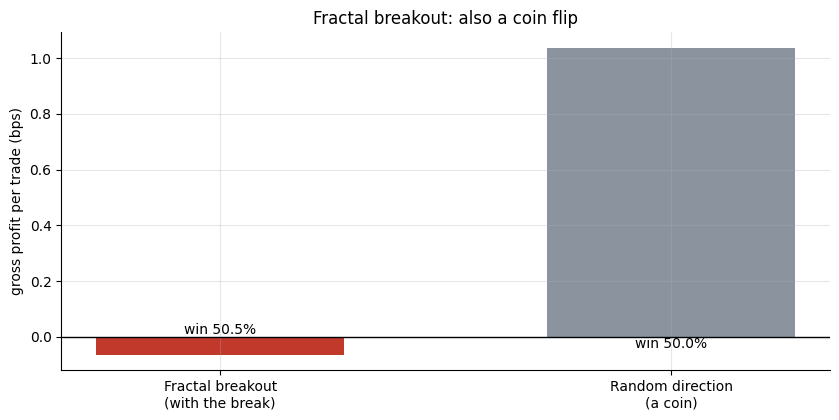

breakout: -0.06 bps/trade  |  coin: +1.04 bps/trade


In [4]:
if HAVE_REAL:
    B = pool_brk(hold_days=5, cost=0.0)
    RB = pool_brk(hold_days=5, cost=0.0, seed=184)
    bm, bw = st.summarize(B, 'ret_gross')['mean_bps'], st.summarize(B, 'ret_gross')['win_rate']*100
    rbm = st.summarize(RB, 'ret_gross')['mean_bps']
else:
    bm, bw, rbm = R['brk_mean'], R['brk_win'], R['rand_brk_mean']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_plot = ax.bar(
    ['Fractal breakout\n(with the break)', 'Random direction\n(a coin)'],
    [bm, rbm], color=[RED, GREY], width=0.55
)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('Fractal breakout: also a coin flip')
for b, w in zip(bars_plot, [bw, 50.0]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, 0),
                ha='center', va='bottom' if b.get_height() < 0 else 'top')
plt.tight_layout(); plt.show()
print('breakout: -0.06 bps/trade  |  coin: +1.04 bps/trade')

The breakout earns **-0.06 bps/trade** — essentially zero, a pure coin flip.  The fractal high or low carries no information about whether price will continue when it finally breaches that level.

## 5 · The verdict

- **Signal — None.** Both the reversal and breakout framings are statistically indistinguishable from noise.  The reversal *underperforms* a coin; the breakout *is* a coin.  No instrument clears the inference bar.
- **Tradability — Mirage.** A gross loss of −4 bps/trade compounds into a significant loser at realistic costs (at 5 bps: *t* = **-2.80**).
- **Beat a coin? — No.** The fractal direction adds *negative* information — both framings would be better off ignoring the direction and flipping a coin.

## 6 · Could you actually trade it?

The fractal fires on ~27% of all trading days — that's high turnover. Even if the gross edge were flat (it isn't), a small per-trade cost would quickly bury it.

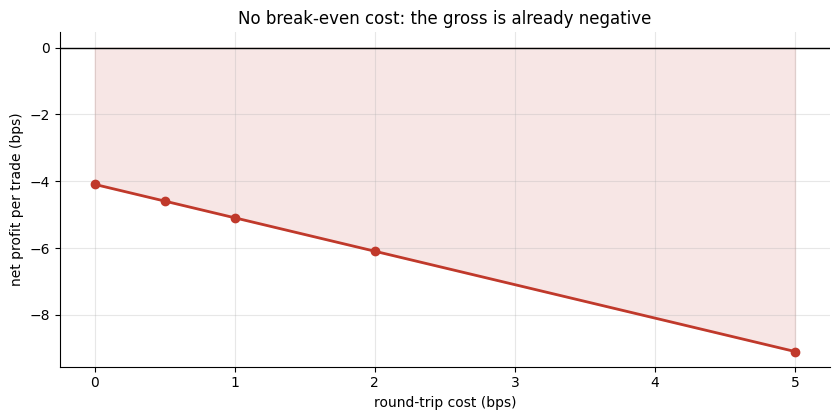

Gross is already -4.09 bps — there is no positive break-even cost.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pool_rev(hold_days=5, cost=c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['cost0'], R['cost05'], R['cost10'], R['cost20'], R['cost50']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n < 0 for n in net], color=RED, alpha=0.12)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('net profit per trade (bps)')
ax.set_title('No break-even cost: the gross is already negative')
plt.tight_layout(); plt.show()
print(f'Gross is already {net[0]:+.2f} bps — there is no positive break-even cost.')

The line starts below zero.  Because the gross edge is already negative, there is **no cost low enough** to make the strategy work — the usual 'it dies at the cost line' story doesn't even apply here, because it was never alive.

## 7 · Going further

- **Is the *engine* broken, or is the market?** The companion notebook plants momentum in a synthetic tape and shows the breakout rule *does* find an edge when one exists — so it's a market statement, not a method flaw.
- **What about the full Alligator system?** Williams used fractals alongside three displaced SMAs (the 'Alligator jaws'). That combination hasn't been studied here; fractal *alone* is the subject. A filter that required the Alligator to be 'awake' would be a different hypothesis.
- **Related work on the desk:**
  - [Study 127 — Williams-R](../../127-williams-r/): the other Williams indicator, same daily frequency, same verdict.
  - [Study 76 — Rice-Paper](../../76-rice-paper/): candlestick chart patterns — the same 'visual pattern vs coin' framework.
  - [Study 21 — Fools-Gold](../../21-fools-gold/): the daily golden cross — breakout family, same ending.

*Think the fractal really does predict direction? Fork this, add a filter (Alligator state, volume, trend regime), and show a fair-bet edge that clears the coin comparison and survives costs. That's the bar.*